# Sales & Demand Forecasting for Businesses
### Machine Learning Task 1 – Future Interns
### Name: V R POOJA


## Problem Statement

The objective of this project is to build a sales forecasting model using historical retail sales data. 

The model aims to predict future monthly sales and provide business-friendly insights that can support inventory planning, budgeting, and operational decisions.


## Dataset Description

This project uses the Superstore Sales dataset, a retail transaction dataset commonly used for sales analysis and forecasting tasks.

The dataset contains 9,994 transaction records across multiple product categories and regions.

The data spans from 2014 to 2017, providing four years of historical sales information.

For this forecasting task, the **Order Date** and **Sales** columns were primarily used to analyze trends and predict future monthly sales.

The dataset represents a real-world retail business scenario, making it suitable for demand forecasting and business planning analysis.


## Data Cleaning & Preparation

- Converted Order Date column to datetime format  
- Checked for missing values  
- Aggregated transaction-level data into monthly sales  
- Created a Time_Index feature for regression modeling  


## Model Building – Linear Regression

A Linear Regression model was trained using the Time_Index feature to capture the overall sales growth trend.


In [12]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check data type
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [18]:
import os
os.getcwd()


'C:\\Sales_Forecasting_Task1'

In [19]:
import os
os.listdir()


['.ipynb_checkpoints',
 'Sales_Forecasting_Task1.ipynb',
 'Sample - Superstore.csv']

In [21]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [29]:
df['Order Date'].min()
df['Order Date'].max()


Timestamp('2017-12-30 00:00:00')

In [30]:
df['Order Date'].min()

Timestamp('2014-01-03 00:00:00')

In [31]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period("M"))['Sales'].sum()
monthly_sales = monthly_sales.reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

monthly_sales.head()


,Order Date,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


## Sales Trend Visualization


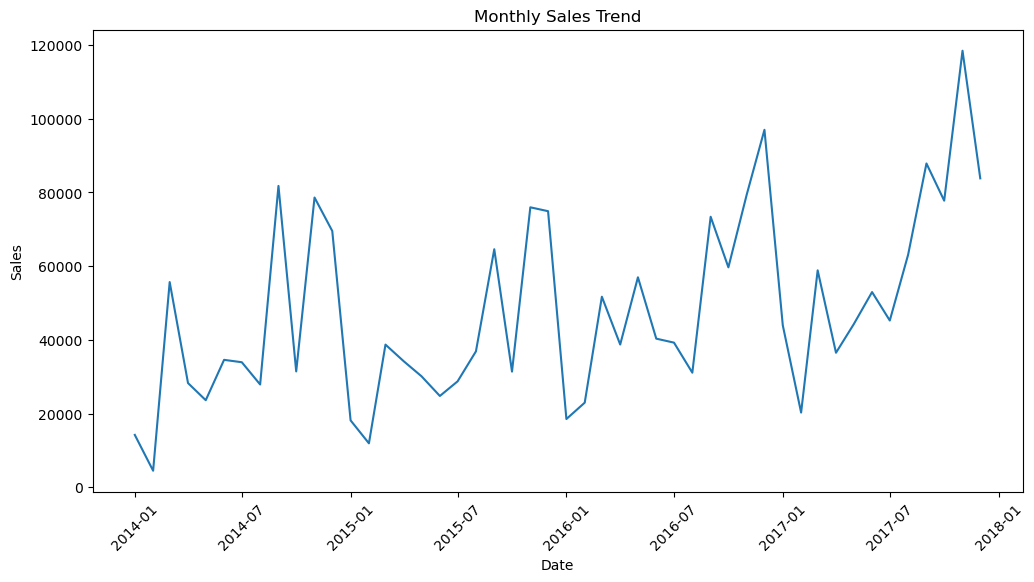

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


## Model Building – Linear Regression

To forecast future sales, a Linear Regression model was used.

Since machine learning models cannot directly understand date values, a numeric feature called **Time_Index** was created. This feature represents the progression of time in monthly order (0, 1, 2, 3, ...).

The Linear Regression model was trained using:

- Input (X): Time_Index  
- Output (y): Monthly Sales  

The model learns the relationship between time and sales, allowing it to capture the overall upward growth trend in the business.

While Linear Regression effectively models the general trend, it does not fully capture seasonal fluctuations in sales.


In [33]:
import numpy as np

monthly_sales['Time_Index'] = np.arange(len(monthly_sales))

monthly_sales.head()


,Order Date,Sales,Time_Index
0,2014-01-01,14236.895,0
1,2014-02-01,4519.892,1
2,2014-03-01,55691.009,2
3,2014-04-01,28295.345,3
4,2014-05-01,23648.287,4


In [37]:
from sklearn.linear_model import LinearRegression

X = monthly_sales[['Time_Index']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [38]:
monthly_sales['Predicted_Sales'] = model.predict(X)

monthly_sales.head()


,Order Date,Sales,Time_Index,Predicted_Sales
0,2014-01-01,14236.895,0,26661.174247
1,2014-02-01,4519.892,1,27563.181779
2,2014-03-01,55691.009,2,28465.189312
3,2014-04-01,28295.345,3,29367.196844
4,2014-05-01,23648.287,4,30269.204376


## Actual vs Predicted Sales Trend

The graph below compares the actual monthly sales with the sales predicted by the Linear Regression model.

The predicted line represents the overall growth trend captured by the model. 
While the model successfully captures the upward trend in sales, it does not fully capture seasonal fluctuations, which explains variations between actual and predicted values.


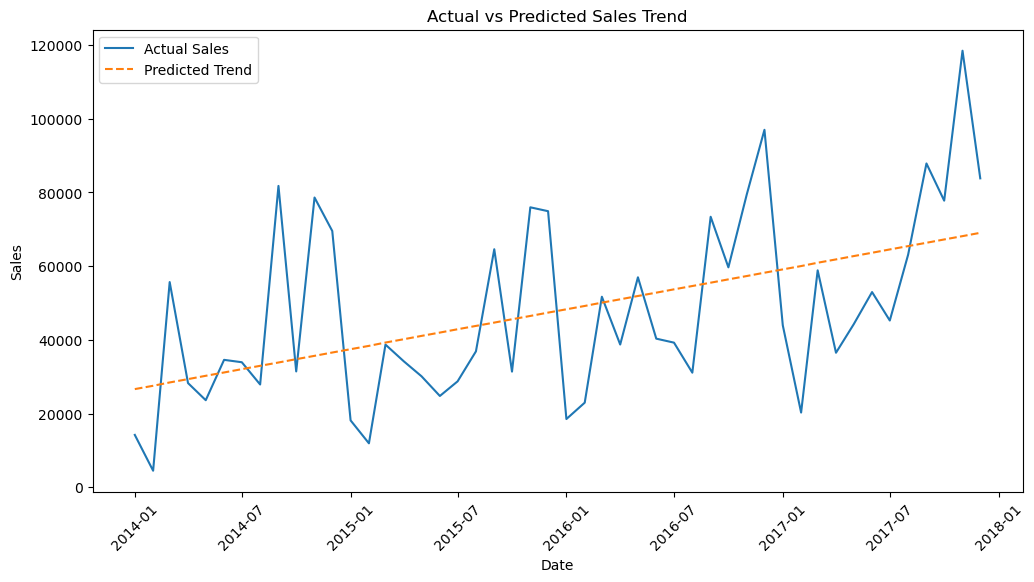

In [40]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label='Actual Sales')
plt.plot(monthly_sales['Order Date'], monthly_sales['Predicted_Sales'], label='Predicted Trend', linestyle='--')

plt.title("Actual vs Predicted Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)

plt.show()


## Model Evaluation

The model performance was evaluated using MAE and RMSE to measure prediction accuracy.


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = model.predict(X)

mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 17457.725724823373
RMSE: 21574.53237223591


## Future Sales Forecast (Next 6 Months)

The trained model was used to predict sales for the next six months beyond the available dataset.


C:\Users\nandini vanka\AppData\Local\Temp\ipykernel_17012\3057558202.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


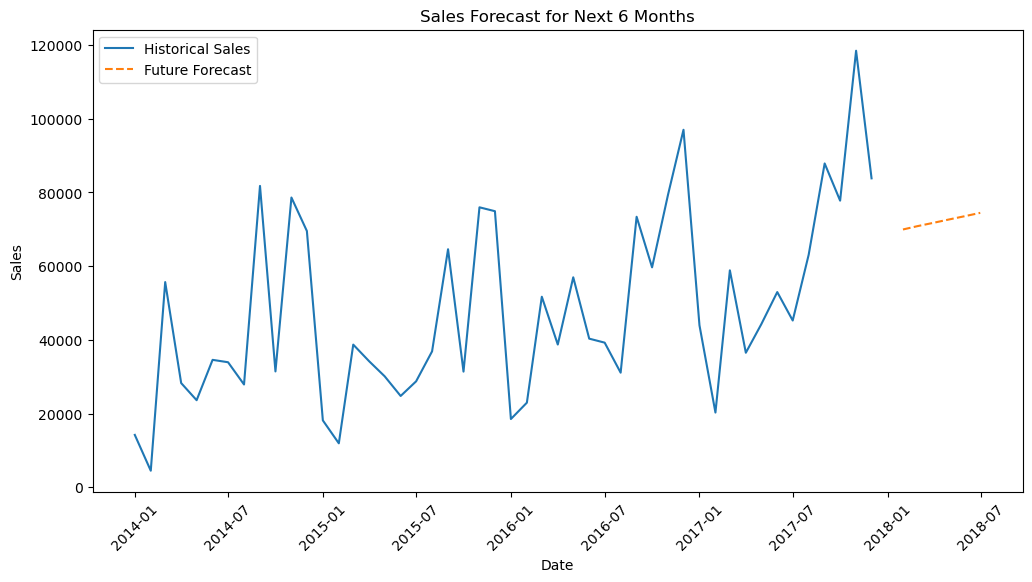

In [54]:
future_dates = pd.date_range(
    start=monthly_sales['Order Date'].max(),
    periods=7,
    freq='M'
)[1:]

plt.figure(figsize=(12,6))

# Historical
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label='Historical Sales')

# Forecast
plt.plot(future_dates, future_predictions, label='Future Forecast', linestyle='--')

plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)

plt.show()


# Business Insights & Forecast Interpretation


## Historical Sales Analysis

The historical sales data from 2014 to 2017 shows a clear upward growth trend. 

There are noticeable seasonal spikes, especially towards the end of each year. 
This suggests that the business experiences higher demand during certain periods, 
possibly due to festive seasons or promotional campaigns.


## Forecasting Approach

To forecast future sales, a Linear Regression model was applied using a time index 
to capture the overall sales trend.

The model was trained on monthly aggregated sales data and used to predict 
sales for the next 6 months beyond the available dataset.


## Model Performance

Mean Absolute Error (MAE): 17,457  
Root Mean Squared Error (RMSE): 21,574  

The model successfully captures the overall upward sales trend. 
However, it does not fully capture seasonal fluctuations, 
which results in moderate prediction errors during peak months.


## Business Implications of Forecast

The model predicts continued growth in sales over the next 6 months, 
with expected monthly sales ranging between approximately 70,000 and 74,000.

Based on this forecast, the business should:

- Prepare for steady growth in product demand
- Increase inventory planning to avoid stockouts
- Allocate sufficient staff to handle increasing operations
- Plan budgets and marketing campaigns aligned with expected sales growth

These insights help business managers make informed strategic decisions.
